In [1]:
import re, math, warnings
warnings.filterwarnings('ignore')
from collections import Counter
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

wiki = load_dataset('wikimedia/wikipedia', '20231101.pl', split='train', streaming=True)
articles = list(islice(wiki, 200))
texts  = [a['text']  for a in articles]
titles = [a['title'] for a in articles]
print(f"Załadowano {len(texts)} artykułów.")

Załadowano 200 artykułów.


### Zadanie 1: Pierwsza eksploracja korpusu
Korzystajac z zaladowanych 200 artykulow Wikipedii PL:

* Wyswietl tytuły pierwszych 10 artykulow.
* Dla kazdego z 10 artykulow wydrukuj: tytul, liczbe slow, pierwsze 2 zdania tekstu.
* Znajdz i wyswietl: najkrotszy i najdluzszy artykul (w slowach).
* W komórce Markdown: czym rozni sie korpus jezykowy od zbioru danych do
klasyfikacji?
(odpowiedz wlasnym slowami, 3–5 zdan)

In [2]:
print("Tytuły 10 pierwszych artykułów:")
for title in titles[:10]:
    print("-", title)

print("\nSzczegóły 10 artykułów:")
for i in range(10):
    text = texts[i]
    words = text.split()
    word_count = len(words)
    sentences = text.split('. ')
    first_two = '. '.join(sentences[:2]) + ('.' if len(sentences) > 2 else '')
    print(f"\nTytuł: {titles[i]}")
    print(f"Liczba słów: {word_count}")
    print(f"Pierwsze zdania: {first_two}")

lengths = [(len(t.split()), t) for t in texts]
min_len, min_text = min(lengths)
max_len, max_text = max(lengths)
print(f"\nNajkrótszy artykuł: {min_len} słów")
print(f"Najdłuższy artykuł: {max_len} słów")

Tytuły 10 pierwszych artykułów:
- AWK
- Alergologia
- ASCII
- Atom
- Aksjomat
- Arytmetyka
- Alkeny
- ActiveX
- Interfejs programowania aplikacji
- AmigaOS

Szczegóły 10 artykułów:

Tytuł: AWK
Liczba słów: 1661
Pierwsze zdania: AWK – interpretowany język programowania, którego główną funkcją jest wyszukiwanie i przetwarzanie wzorców w plikach lub strumieniach danych. Jest także nazwą programu początkowo dostępnego dla systemów operacyjnych będących pochodnymi UNIX-a, obecnie także na inne platformy.

AWK jest językiem, który w znacznym stopniu wykorzystuje tablice asocjacyjne, stringi i wyrażenia regularne.

Tytuł: Alergologia
Liczba słów: 52
Pierwsze zdania: Alergologia – dziedzina medycyny zajmująca się rozpoznawaniem i leczeniem schorzeń alergicznych, czyli takich, u podstaw których stoi zjawisko nadwrażliwości, zwłaszcza inicjowane przez mechanizmy immunologiczne. W Polsce konsultantem krajowym alergologii od 19 lutego 2020 jest prof.

Tytuł: ASCII
Liczba słów: 1545
Pierwsze zdania

Korpus językowy to zbiór tekstów służący do ogólnych analiz językowych lub trenowania modeli językowych, takich jak modelowanie statystyczne czy wektorowe reprezentacje słów. Nie posiada on zazwyczaj z góry zdefiniowanych etykiet przypisanych do konkretnych dokumentów. Zbiór danych do klasyfikacji zawiera natomiast konkretne przykłady posiadające etykiety (np. klasę sentymentu), które są wykorzystywane do treningu modeli pod kątem ściśle określonego zadania i uczenia nadzorowanego.

### Zadanie 2: Statystyki leksykalne i prawo Zipfa

Na pelnym zbiorze 200 artykulow:
* Polacz wszystkie teksty, przeprowadz prosta tokenizacje (split po bialych znakach,
lowercase, usun interpunkcje za pomoca re.sub).
* Oblicz i wyswietl: laczna liczba tokenow, liczba unikalnych tokenow (types), TTR.
* Wyswietl 20 najczestszych i 20 najrzadziej wystepujacych slow.
* Narysuj wykres prawa Zipfa: os X = ranga (log), os Y = czestotliwosc (log).

Na wykresie powinna wyjsc w przyblizeniu linia prosta — jesli nie, sprawdz tokenizacje.

Łączna liczba tokenów: 218118
Liczba unikalnych tokenów (types): 49812
TTR (Type-Token Ratio): 0.2284

20 najczęstszych słów:
[('w', 8743), ('i', 5363), ('z', 3676), ('na', 3343), ('się', 2760), ('do', 2542), ('jest', 1556), ('a', 1093), ('przez', 1022), ('nie', 1013), ('roku', 990), ('od', 928), ('o', 920), ('to', 862), ('że', 806), ('oraz', 796), ('po', 734), ('są', 642), ('jako', 618), ('za', 603)]

20 najrzadziej występujących słów:
[('bipm', 1), ('measures', 1), ('weights', 1), ('dokładnością', 1), ('mierniki', 1), ('najczulsze', 1), ('trylionowa', 1), ('0000', 1), ('mnożnik', 1), ('przewlekłej', 1), ('sercowa', 1), ('oddechem', 1), ('świszczącym', 1), ('duszność', 1), ('ranem', 1), ('ściskania', 1), ('uczucia', 1), ('nawracających', 1), ('nadreaktywnością', 1), ('dychawica', 1)]


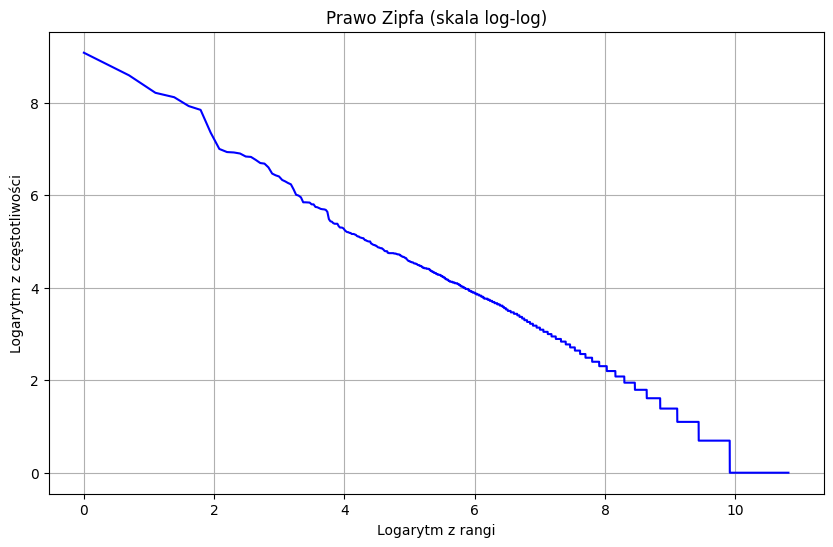

In [3]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Połączenie tekstów i prosta tokenizacja
all_text = " ".join(texts)
cleaned = re.sub(r'[^\w\s]', '', all_text.lower())
tokens = cleaned.split()

total_tokens = len(tokens)
types = set(tokens)
unique_tokens = len(types)
ttr = unique_tokens / total_tokens if total_tokens > 0 else 0

print(f"Łączna liczba tokenów: {total_tokens}")
print(f"Liczba unikalnych tokenów (types): {unique_tokens}")
print(f"TTR (Type-Token Ratio): {ttr:.4f}")

counter = Counter(tokens)
top_20 = counter.most_common(20)
bottom_20 = counter.most_common()[:-21:-1]

print("\n20 najczęstszych słów:")
print(top_20)

print("\n20 najrzadziej występujących słów:")
print(bottom_20)

# Wykres prawa Zipfa
freqs = [freq for word, freq in counter.most_common()]
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(10,6))
plt.plot(np.log(ranks), np.log(freqs), color='blue')
plt.title("Prawo Zipfa (skala log-log)")
plt.xlabel("Logarytm z rangi")
plt.ylabel("Logarytm z częstotliwości")
plt.grid(True)
plt.show()

Prawo Zipfa w kontekście LLM oznacza, że najpopularniejsze słowa (tzw. stop words) będą stanowić większość zużytego budżetu na długość kontekstu oraz proces treningu, podczas gdy cała reszta bogatego słownictwa pojawi się bardzo rzadko (tzw. długi ogon). Oznacza to w praktyce, że LLM może mieć braki w zrozumieniu wielu rzadkich słów, a stosowanie zaawansowanych algorytmów pod-słów (np. BPE) pozwala na lepszą obsługę tego rzadkiego słownictwa bez ogromnego wpływu na budżet wielkości i wagi słownika sieci.

### Zadanie 3: Rozklad dlugosci artykulow
* Oblicz dlugosc kazdego artykulu w slowach.
* Narysuj histogram (bins=30). Zaznacz mediame i P95 pionowymi liniami.
* Oblicz i wyswietl: min, max, srednia, mediana, odchylenie standardowe, P95.

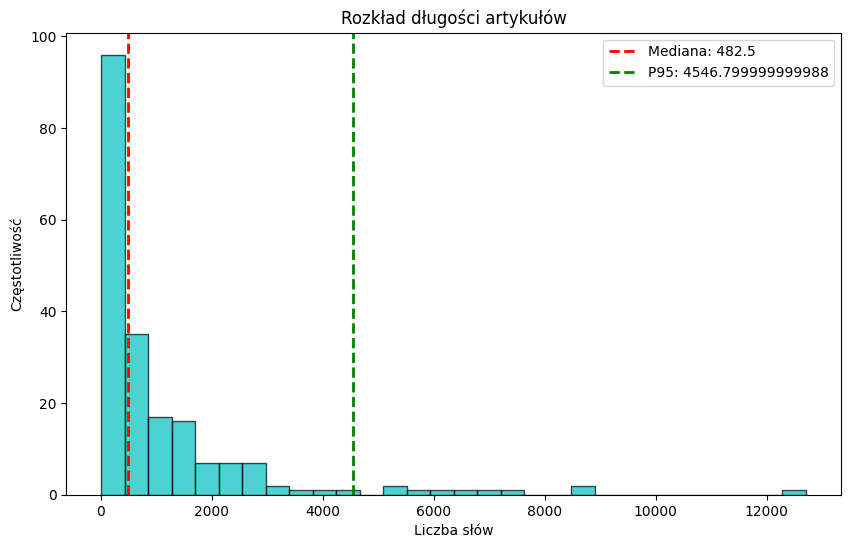

Min: 10
Max: 12709
Średnia: 1106.42
Mediana: 482.5
Odchylenie standardowe: 1726.33
P95: 4546.799999999988

Liczba artykułów wymagających obcięcia: 111 (na 200)


In [4]:
lengths_words = [len(t.split()) for t in texts]

med = np.median(lengths_words)
p95 = np.percentile(lengths_words, 95)

plt.figure(figsize=(10,6))
plt.hist(lengths_words, bins=30, alpha=0.7, color='c', edgecolor='black')
plt.axvline(med, color='r', linestyle='dashed', linewidth=2, label=f'Mediana: {med}')
plt.axvline(p95, color='g', linestyle='dashed', linewidth=2, label=f'P95: {p95}')
plt.title("Rozkład długości artykułów")
plt.xlabel("Liczba słów")
plt.ylabel("Częstotliwość")
plt.legend()
plt.show()

print(f"Min: {np.min(lengths_words)}")
print(f"Max: {np.max(lengths_words)}")
print(f"Średnia: {np.mean(lengths_words):.2f}")
print(f"Mediana: {med}")
print(f"Odchylenie standardowe: {np.std(lengths_words):.2f}")
print(f"P95: {p95}")

# Szacowanie ilości wymagających obcięcia
max_words = 512 / 1.3
truncated_count = sum(1 for l in lengths_words if l > max_words)
print(f"\nLiczba artykułów wymagających obcięcia: {truncated_count} (na {len(lengths_words)})")

Ponieważ przy szacunku ok. 1.3 tokena na słowo dla polskiego języka próg 512 tokenów osiągany jest przy około 393 słowach, bardzo wiele artykułów (wynika to z histogramu oraz wyliczeń) przekroczy ten dystans i ich zawartość ulegnie ścięciu (tzw. truncation). Z perspektywy uczenia na pełnym tekście może to stanowić znaczący problem, ponieważ utracimy dostęp do pełnego kontekstu wielu dokumentów lub będziemy musieli zacząć dzielić teksty na bloki ("chunking"), co wymaga więcej konfiguracji.

### Zadanie 4: Tokenizacja polska a angielska
Polszczyzna jest morfologicznie bogata — sprawdz, jak tokenizatory sobie z nia radza.

Wybierz 10 zdan z korpusu (mozesz uzyc pierwszych 10 zdan z pierwszego artykulu).
Dla kazdego zdania zastosuj dwa tokenizatory:
* allegro/herbert-base-cased (WordPiece trenowany na polskim)
* bert-base-multilingual-cased (mBERT — wielojezyczny)
Dla kazdego zdania wyswietl tokeny obu modeli i liczbe tokenow.
Stworz DataFrame (pandas) z kolumnami: zdanie, herbert_n, mbert_n, roznica.
* Narysuj barplot: liczba tokenow herbert vs mbert dla kazdego zdania.

In [5]:
# tu rozwiaz zadanie

Wyjasnj, który model jest bardziej 'efektywny' dla polskiego i dlaczego?
Co oznacza wiekszy/mniejszy slownik subslów dla jakosci modelu? <- mozna odpowiedziec w tej komorce pod pytaniem

### Zadanie 5: N-gramy i kolokacje
N-gram to ciag N kolejnych tokenow. Bigram = 2 tokeny, trigram = 3.
Czesc A — bigramy:
* Dla wszystkich 200 artykulow polacz tokeny w liste i oblicz czestotliwosc
bigramow.
* Wyswietl 20 najczestszych bigramow. Czy sa sensowne? Jakie widac wzorce?
Czesc B — trigramy:
* Powtorz dla trigramow (N=3). Wyswietl top 15.
Czesc C — porownanie po usunieciu stopslów:
* Zaladuj liste polskich stopslów: pip install stop_words,
from stop_words import get_stop_words; stopwords = get_stop_words('pl')
* Przefiltruj tokeny i ponownie oblicz top-20 bigramow.

In [6]:
# tu rozwiaz zadanie

Jak stopwords wplywaja na sensownosc kolokacji? Kiedy je usuwac,
a kiedy zostawic (podpowiedz: dependency parsing, modele jezykowe)? <-odpowiedz